# Détection d'intrusions — Log Network
## Projet IDS | Apprentissage supervisé — CNN 1D

In [1]:
import pandas as pd
df = pd.read_csv('../data/Week_filtered.csv')
print(f"Shape : {df.shape}")
print(f"\nColonnes : {df.columns.tolist()}")
print(f"\nDistribution Label :")
print(df['Label'].value_counts())
print(f"\nValeurs manquantes :")
print(df.isnull().sum().sum())
print(f"\nDoublons : vérification ignorée (dataset volumineux)")

Shape : (543734, 79)

Colonnes : ['Destination Port', 'Flow Duration', 'Total Fwd Packets', 'Total Backward Packets', 'Total Length of Fwd Packets', 'Total Length of Bwd Packets', 'Fwd Packet Length Max', 'Fwd Packet Length Min', 'Fwd Packet Length Mean', 'Fwd Packet Length Std', 'Bwd Packet Length Max', 'Bwd Packet Length Min', 'Bwd Packet Length Mean', 'Bwd Packet Length Std', 'Flow Bytes/s', 'Flow Packets/s', 'Flow IAT Mean', 'Flow IAT Std', 'Flow IAT Max', 'Flow IAT Min', 'Fwd IAT Total', 'Fwd IAT Mean', 'Fwd IAT Std', 'Fwd IAT Max', 'Fwd IAT Min', 'Bwd IAT Total', 'Bwd IAT Mean', 'Bwd IAT Std', 'Bwd IAT Max', 'Bwd IAT Min', 'Fwd PSH Flags', 'Bwd PSH Flags', 'Fwd URG Flags', 'Bwd URG Flags', 'Fwd Header Length', 'Bwd Header Length', 'Fwd Packets/s', 'Bwd Packets/s', 'Min Packet Length', 'Max Packet Length', 'Packet Length Mean', 'Packet Length Std', 'Packet Length Variance', 'FIN Flag Count', 'SYN Flag Count', 'RST Flag Count', 'PSH Flag Count', 'ACK Flag Count', 'URG Flag Count', 

## 2. Preprocessing
Nettoyage des doublons, valeurs manquantes et infinies.
Encodage des labels et normalisation MinMaxScaler.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
import warnings
warnings.filterwarnings('ignore')

df = pd.read_csv('../data/Week_filtered.csv')
df.columns = df.columns.str.strip()

print(f"Colonnes : {df.columns.tolist()}")
print(f"\nShape avant : {df.shape}")

# 1. Supprimer doublons
df = df.drop_duplicates()
print(f"Après doublons : {df.shape}")

# 2. Supprimer valeurs manquantes
df = df.dropna()
print(f"Après NaN : {df.shape}")

# 3. Supprimer valeurs infinies
df = df.replace([np.inf, -np.inf], np.nan).dropna()
print(f"Après inf : {df.shape}")

print(f"\n✅ Shape final : {df.shape}")
display(df.head(5))

Colonnes : ['Destination Port', 'Flow Duration', 'Total Fwd Packets', 'Total Backward Packets', 'Total Length of Fwd Packets', 'Total Length of Bwd Packets', 'Fwd Packet Length Max', 'Fwd Packet Length Min', 'Fwd Packet Length Mean', 'Fwd Packet Length Std', 'Bwd Packet Length Max', 'Bwd Packet Length Min', 'Bwd Packet Length Mean', 'Bwd Packet Length Std', 'Flow Bytes/s', 'Flow Packets/s', 'Flow IAT Mean', 'Flow IAT Std', 'Flow IAT Max', 'Flow IAT Min', 'Fwd IAT Total', 'Fwd IAT Mean', 'Fwd IAT Std', 'Fwd IAT Max', 'Fwd IAT Min', 'Bwd IAT Total', 'Bwd IAT Mean', 'Bwd IAT Std', 'Bwd IAT Max', 'Bwd IAT Min', 'Fwd PSH Flags', 'Bwd PSH Flags', 'Fwd URG Flags', 'Bwd URG Flags', 'Fwd Header Length', 'Bwd Header Length', 'Fwd Packets/s', 'Bwd Packets/s', 'Min Packet Length', 'Max Packet Length', 'Packet Length Mean', 'Packet Length Std', 'Packet Length Variance', 'FIN Flag Count', 'SYN Flag Count', 'RST Flag Count', 'PSH Flag Count', 'ACK Flag Count', 'URG Flag Count', 'CWE Flag Count', 'ECE

,Destination Port,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,...,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
0,80,115550790,31,33,318,38380,318,0,10.258065,57.114486,...,32,29534.636364,20922.826407,92617,22941,1.002161e+07,8209.967001,10025078,9998039,BENIGN
1,443,5292756,6,4,611,168,517,0,101.833333,204.305082,...,20,0.000000,0.000000,0,0,0.000000e+00,0.000000,0,0,BENIGN
2,21,3,2,0,14,0,14,0,7.000000,9.899495,...,32,0.000000,0.000000,0,0,0.000000e+00,0.000000,0,0,FTP-Patator
3,54045,41,1,1,2,6,2,2,2.000000,0.000000,...,24,0.000000,0.000000,0,0,0.000000e+00,0.000000,0,0,PortScan
4,80,1023,2,0,0,0,0,0,0.000000,0.000000,...,32,0.000000,0.000000,0,0,0.000000e+00,0.000000,0,0,DoS Hulk


In [3]:
# Encoder les labels
le = LabelEncoder()
df['Label_encoded'] = le.fit_transform(df['Label'])

print("Correspondance Label → encodage :")
for original, encoded in zip(le.classes_, le.transform(le.classes_)):
    print(f"  {original:40s} → {encoded}")

print(f"\nDistribution :")
print(df['Label_encoded'].value_counts())

Correspondance Label → encodage :
  BENIGN                                   → 0
  Bot                                      → 1
  DDoS                                     → 2
  DoS GoldenEye                            → 3
  DoS Hulk                                 → 4
  DoS Slowhttptest                         → 5
  DoS slowloris                            → 6
  FTP-Patator                              → 7
  PortScan                                 → 8
  SSH-Patator                              → 9
  Web Attack � Brute Force                 → 10
  Web Attack � Sql Injection               → 11
  Web Attack � XSS                         → 12

Distribution :
Label_encoded
0     194395
2     100824
4      76080
8      66924
3      10286
7       5931
6       5385
5       5228
9       3219
1       1948
10      1470
12       652
11        21
Name: count, dtype: int64


In [4]:
feature_cols = [col for col in df.columns 
                if col not in ['Label_encoded', 'Label']] 

X = df[feature_cols].values
y = df['Label_encoded'].values

# Normalisation entre 0 et 1
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)

print(f"✅ X shape : {X_scaled.shape}")
print(f"✅ y shape : {y.shape}")
print(f"✅ Classes : {len(np.unique(y))}")
print(f"✅ Features : {len(feature_cols)}")


✅ X shape : (472363, 78)
✅ y shape : (472363,)
✅ Classes : 13
✅ Features : 78


In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y,
    test_size    = 0.2,
    random_state = 42,
    stratify     = y
)

print(f"✅ Train : {X_train.shape[0]} lignes")
print(f"✅ Test  : {X_test.shape[0]} lignes")

print(f"\nDistribution train :")
print(pd.Series(y_train).value_counts())

✅ Train : 377890 lignes
✅ Test  : 94473 lignes

Distribution train :
0     155516
2      80659
4      60864
8      53539
3       8229
7       4745
6       4308
5       4182
9       2575
1       1558
10      1176
12       522
11        17
Name: count, dtype: int64


In [6]:

X_train_cnn = X_train.reshape(X_train.shape[0], X_train.shape[1], 1)
X_test_cnn  = X_test.reshape(X_test.shape[0],  X_test.shape[1],  1)

print(f"✅ X_train_cnn : {X_train_cnn.shape}")
print(f"✅ X_test_cnn  : {X_test_cnn.shape}")


✅ X_train_cnn : (377890, 78, 1)
✅ X_test_cnn  : (94473, 78, 1)


## 3. Modèle — CNN 1D
Réseau de neurones convolutif 1D adapté aux données tabulaires.
Architecture : 3 blocs Conv1D + BatchNormalization + Dropout.

In [7]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, Flatten, Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.utils import to_categorical
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
import matplotlib.pyplot as plt
import numpy as np
import pickle

print(f"✅ TensorFlow : {tf.__version__}")

✅ TensorFlow : 2.21.0


In [8]:
n_classes = len(np.unique(y))

y_train_cat = to_categorical(y_train, num_classes=n_classes)
y_test_cat  = to_categorical(y_test,  num_classes=n_classes)

print(f"✅ Nombre de classes : {n_classes}")
print(f"✅ y_train_cat shape : {y_train_cat.shape}")
print(f"✅ y_test_cat shape  : {y_test_cat.shape}")

✅ Nombre de classes : 13
✅ y_train_cat shape : (377890, 13)
✅ y_test_cat shape  : (94473, 13)


## 4. Évaluation du modèle

In [9]:
model_cnn = Sequential([
    # Bloc 1 — Extraction features locales
    Conv1D(64, kernel_size=3, activation='relu',
           input_shape=(X_train_cnn.shape[1], 1), padding='same'),
    BatchNormalization(),
    MaxPooling1D(pool_size=2),
    Dropout(0.3),

    # Bloc 2 — Patterns plus complexes
    Conv1D(128, kernel_size=3, activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling1D(pool_size=2),
    Dropout(0.3),

    # Bloc 3 — Affinage
    Conv1D(64, kernel_size=3, activation='relu', padding='same'),
    BatchNormalization(),
    Dropout(0.3),

    # Classification
    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.4),
    Dense(64, activation='relu'),
    Dense(n_classes, activation='softmax')
])

model_cnn.compile(
    optimizer = 'adam',
    loss      = 'categorical_crossentropy',
    metrics   = ['accuracy']
)

model_cnn.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 78, 64)         │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 78, 64)         │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 39, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 39, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 39, 128)        │        24,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 39, 128)        │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_1 (MaxPooling1D)  │ (None, 19, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 19, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_2 (Conv1D)               │ (None, 19, 64)         │        24,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 19, 64)         │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 19, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1216)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       155,776 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 13)             │           845 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 215,501 (841.80 KB)

 Trainable params: 214,989 (839.80 KB)

 Non-trainable params: 512 (2.00 KB)

In [10]:
early_stop = EarlyStopping(
    monitor              = 'val_loss',
    patience             = 5,
    restore_best_weights = True
)

history = model_cnn.fit(
    X_train_cnn, y_train_cat,
    epochs           = 20,
    batch_size       = 256,
    validation_split = 0.2,
    callbacks        = [early_stop],
    verbose          = 1
)

print("✅ Entraînement terminé !")

Epoch 1/20
1181/1181 ━━━━━━━━━━━━━━━━━━━━ 106s 85ms/step - accuracy: 0.9198 - loss: 0.2495 - val_accuracy: 0.7851 - val_loss: 0.8449
Epoch 2/20
1181/1181 ━━━━━━━━━━━━━━━━━━━━ 136s 80ms/step - accuracy: 0.9758 - loss: 0.0762 - val_accuracy: 0.9744 - val_loss: 0.0758
Epoch 3/20
1181/1181 ━━━━━━━━━━━━━━━━━━━━ 140s 78ms/step - accuracy: 0.9818 - loss: 0.0568 - val_accuracy: 0.9787 - val_loss: 0.0774
Epoch 4/20
1181/1181 ━━━━━━━━━━━━━━━━━━━━ 94s 79ms/step - accuracy: 0.9841 - loss: 0.0489 - val_accuracy: 0.9854 - val_loss: 0.0391
Epoch 5/20
1181/1181 ━━━━━━━━━━━━━━━━━━━━ 93s 79ms/step - accuracy: 0.9855 - loss: 0.0439 - val_accuracy: 0.9845 - val_loss: 0.0448
Epoch 6/20
1181/1181 ━━━━━━━━━━━━━━━━━━━━ 94s 79ms/step - accuracy: 0.9863 - loss: 0.0416 - val_accuracy: 0.7665 - val_loss: 1.3388
Epoch 7/20
1181/1181 ━━━━━━━━━━━━━━━━━━━━ 255s 175ms/step - accuracy: 0.9867 - loss: 0.0395 - val_accuracy: 0.9472 - val_loss: 0.2076
Epoch 8/20
1181/1181 ━━━━━━━━━━━━━━━━━━━━ 90s 76ms/step - accuracy: 0.9

In [11]:
y_pred_proba = model_cnn.predict(X_test_cnn)
y_pred       = np.argmax(y_pred_proba, axis=1)
y_true       = np.argmax(y_test_cat,  axis=1)

print("=" * 60)
print(f"🎯 Accuracy : {accuracy_score(y_true, y_pred)*100:.2f}%")
print("=" * 60)
print(classification_report(y_true, y_pred,
      target_names=le.classes_))

2953/2953 ━━━━━━━━━━━━━━━━━━━━ 10s 3ms/step
🎯 Accuracy : 98.55%
                            precision    recall  f1-score   support

                    BENIGN       1.00      0.98      0.99     38879
                       Bot       1.00      0.62      0.76       390
                      DDoS       1.00      0.99      0.99     20165
             DoS GoldenEye       0.96      0.99      0.98      2057
                  DoS Hulk       0.96      1.00      0.98     15216
          DoS Slowhttptest       0.95      0.97      0.96      1046
             DoS slowloris       0.96      0.95      0.96      1077
               FTP-Patator       0.99      0.99      0.99      1186
                  PortScan       1.00      1.00      1.00     13385
               SSH-Patator       0.92      0.97      0.94       644
  Web Attack � Brute Force       0.48      0.91      0.63       294
Web Attack � Sql Injection       0.00      0.00      0.00         4
          Web Attack � XSS       0.00      0.00    

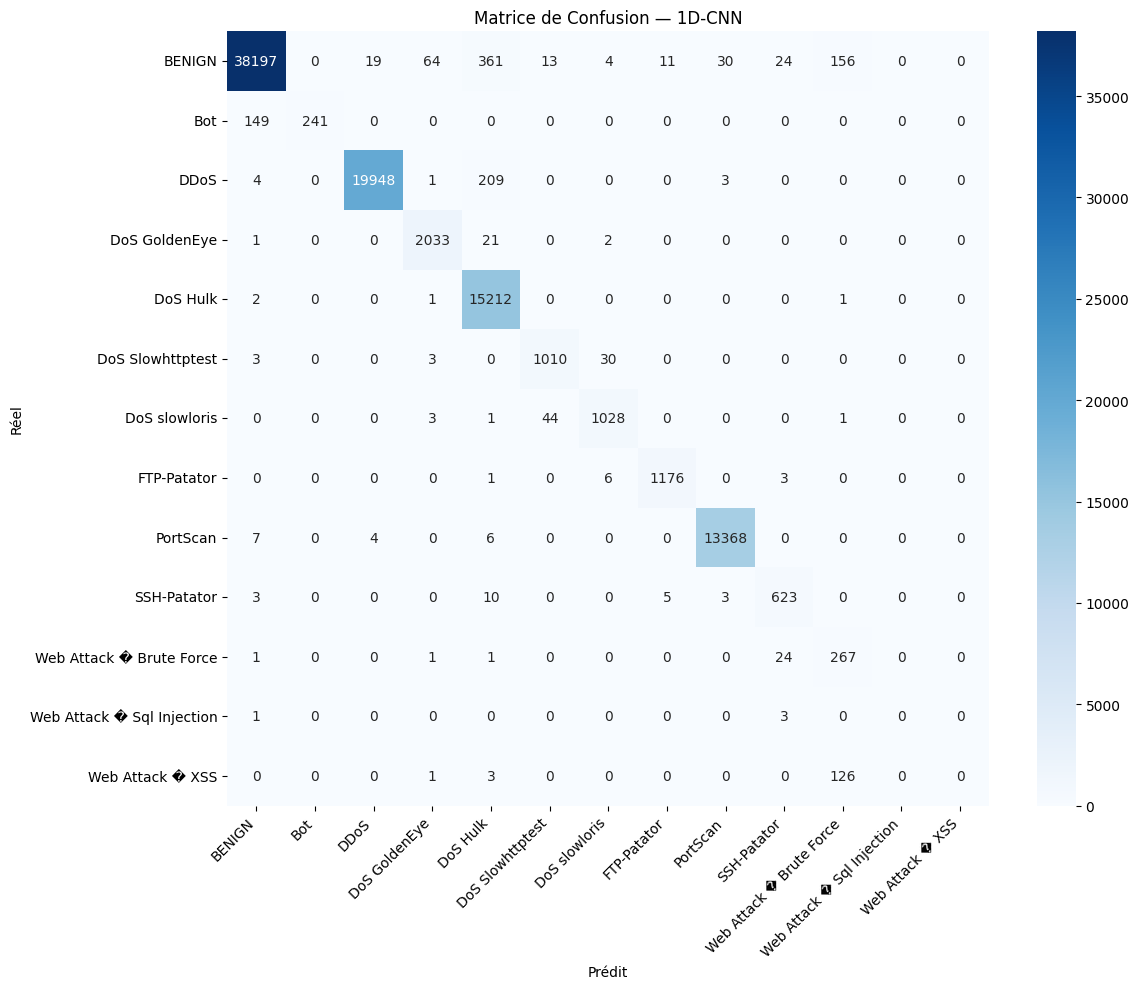

In [12]:
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_,
            yticklabels=le.classes_)
plt.title("Matrice de Confusion — 1D-CNN")
plt.ylabel("Réel")
plt.xlabel("Prédit")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

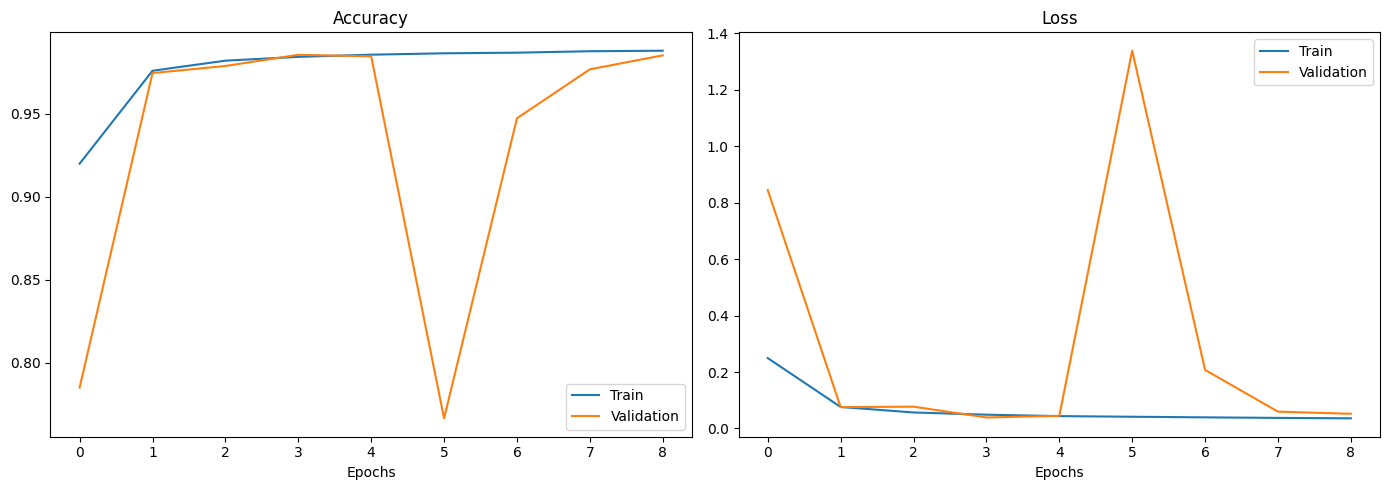

In [13]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(history.history['accuracy'],     label='Train')
ax1.plot(history.history['val_accuracy'], label='Validation')
ax1.set_title("Accuracy")
ax1.set_xlabel("Epochs")
ax1.legend()

ax2.plot(history.history['loss'],     label='Train')
ax2.plot(history.history['val_loss'], label='Validation')
ax2.set_title("Loss")
ax2.set_xlabel("Epochs")
ax2.legend()

plt.tight_layout()

plt.show()

In [14]:
# DataFrame avec vraies valeurs et prédictions
results = pd.DataFrame({
    'Vrai_label': le.inverse_transform(y_true),
    'Prediction': le.inverse_transform(y_pred)
})
results.head(10)

,Vrai_label,Prediction
0,BENIGN,DoS GoldenEye
1,BENIGN,BENIGN
2,DoS slowloris,DoS slowloris
3,DDoS,DDoS
4,DDoS,DDoS
5,BENIGN,BENIGN
6,PortScan,PortScan
7,DDoS,DDoS
8,BENIGN,BENIGN
9,DoS Slowhttptest,DoS Slowhttptest


## 5. Export — output normalisé pour la corrélation
## 6. Sauvegarde du modèle

In [15]:
import pandas as pd, os

base = r"C:\Users\asus\Desktop\IDS\Supervisé\notebooks\outputs"
os.makedirs(base, exist_ok=True)

df_network_normalized = pd.DataFrame({
    "timestamp"     : "unknown",        # absent du dataset CIC-IDS2017
    "source_ip"     : "unknown",        # absent du dataset CIC-IDS2017
    "dest_ip"       : "unknown",        # absent du dataset CIC-IDS2017
    "destination_port" : df.iloc[
                         list(range(len(y_pred))), 
                         df.columns.tolist().index("Destination Port")
                         ].values if "Destination Port" in df.columns else "unknown",
    "log_source"    : "network",
    "anomaly_score" : [max(row) for row in y_pred_proba],
    "prediction"    : le.inverse_transform(y_pred),
    "alert_level"   : ["NORMAL" if le.inverse_transform([p])[0] == "BENIGN"
                       else "HIGH"
                       for p in y_pred],
})

df_network_normalized.to_csv(
    os.path.join(base, "network_output_normalized.csv"), index=False
)
print("✅ network_output_normalized.csv sauvegardé")
print(f"   {len(df_network_normalized)} lignes")
print(df_network_normalized.head()) 

✅ network_output_normalized.csv sauvegardé
   94473 lignes
  timestamp source_ip  dest_ip  destination_port log_source  anomaly_score  \
0   unknown   unknown  unknown                80    network       0.875186   
1   unknown   unknown  unknown               443    network       1.000000   
2   unknown   unknown  unknown                21    network       1.000000   
3   unknown   unknown  unknown             54045    network       1.000000   
4   unknown   unknown  unknown                80    network       1.000000   

      prediction alert_level  
0  DoS GoldenEye        HIGH  
1         BENIGN      NORMAL  
2  DoS slowloris        HIGH  
3           DDoS        HIGH  
4           DDoS        HIGH  
